# Business Case · Expectativa de Vida Global 2016–2025
### Atividade — Pipeline completo de EDA, Data Munging, Feature Engineering, Correlação, Modelagem Estatística e Preditiva

Baseado na estrutura da Aula 18, adaptado ao novo dataset `expectativa_vida_2016_2025.csv`.

## 1. Instalando e Carregando os Pacotes

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

import xgboost as xgb

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

## 2. Carregando os Dados

In [3]:
df = pd.read_csv('expectativa_vida_2016_2025.csv')
df.shape

(1945, 22)

In [5]:
df.dtypes

Country                                str
Year                                   str
Status                                 str
Life expectancy                        str
Adult Mortality                      int64
infant deaths                        int64
Alcohol                                str
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                                   str
under-five deaths                    int64
Polio                              float64
Total expenditure                      str
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                    str
 Population                            str
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources        str
Schooling                              str
dtype: object

In [6]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2016,Developing,65.04,260,61,0.07,91.14,64.04,1155,19.12,82,6.41,8.21,66.53,0.10,765.23,34225634,16.98,17.20,0.41,10.03
1,Afghanistan,2017,Developing,66.98,259,61,0.04,113.06,66.54,1146,19.33,83,6.92,8.05,65.84,0.06,931.11,34832494,16.69,17.37,0.44,9.93
2,Afghanistan,2018,Developing,68.02,253,60,0.05,133.26,67.86,1152,19.53,84,7.37,8,65.53,0.01,1118.09,35204149,16.98,17.18,0.42,9.95
3,Afghanistan,2019,Developing,68.12,248,58,0.17,151.63,67.36,1133,19.12,83,7.69,8.12,66.10,0.00,1309.56,35817726,17.08,16.97,0.4,9.91
4,Afghanistan,2020,Developing,69.27,244,57,0.23,169.99,67.56,1097,18.91,82,8.14,8.28,66.48,0.00,1492.86,36143541,16.72,16.60,0.39,10.01


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,1945,233,Cuba,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,1945,37,2024,193,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Status,1945,8,Developing,1579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Life expectancy,1937,1405,90,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adult Mortality,1945.0,NaN,NaN,NaN,142.385604,103.191118,-5.0,64.0,130.0,195.0,1200.0
infant deaths,1945.0,NaN,NaN,NaN,21.099743,81.81074,0.0,0.0,0.0,12.0,948.0
Alcohol,1924,657,0,84,NaN,NaN,NaN,NaN,NaN,NaN,NaN
percentage expenditure,1945.0,NaN,NaN,NaN,119.253599,91.879661,19.87,60.18,117.92,162.15,1095.99
Hepatitis B,1935.0,NaN,NaN,NaN,84.288584,23.626058,6.53,83.54,94.57,98.28,99.0
Measles,1945.0,NaN,NaN,NaN,1412.139846,7664.933285,0.0,0.0,0.0,149.0,92356.0


## 3. Análise Exploratória de Dados (EDA) — Etapa 1

### 3.1 — Inspeção Inicial

In [8]:
# Valores ausentes por coluna
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
missing_pct

GDP                                1.131105
Income composition of resources    1.079692
Alcohol                            1.079692
Schooling                          0.616967
Total expenditure                  0.616967
Hepatitis B                        0.514139
 Population                        0.462725
Life expectancy                    0.411311
 BMI                               0.308483
dtype: float64

**Q2 — Quanto de dados ausentes existem? Quais colunas têm >10% de missings?**

Nenhuma coluna tem mais de ~1.1% de valores ausentes (Alcohol, GDP, Income composition of resources, Schooling,
Total expenditure, Hepatitis B, BMI, Population, Life expectancy). Como todos os percentuais são baixos (<1.5%),
a estratégia adotada será **imputação** (mediana por país, com fallback por Status e fallback global), sem
necessidade de remover colunas inteiras.

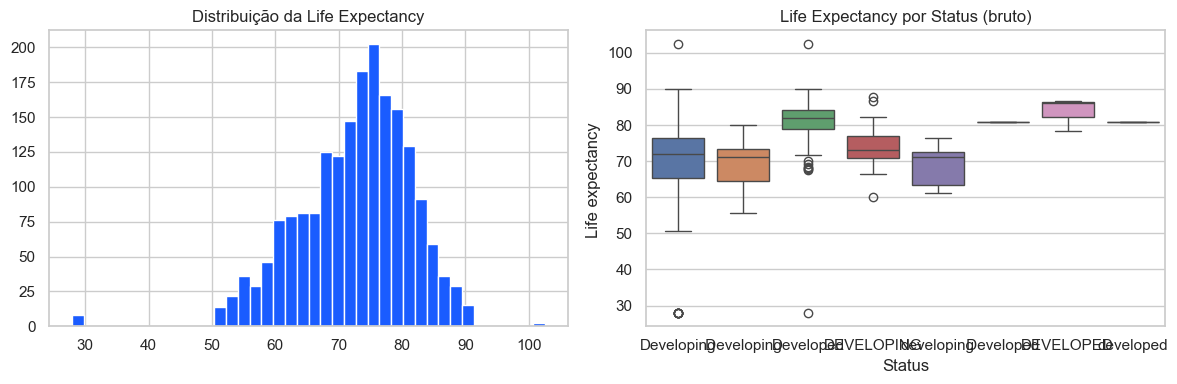

In [9]:
# Distribuição da variável-alvo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.to_numeric(df['Life expectancy '].astype(str).str.replace(',', '.').replace('-', np.nan), errors='coerce').hist(ax=axes[0], bins=40, color="#1A5CFF")
axes[0].set_title('Distribuição da Life Expectancy')

sns.boxplot(x='Status', y=pd.to_numeric(df['Life expectancy '].astype(str).str.replace(',', '.').replace('-', np.nan), errors='coerce'),
            data=df, ax=axes[1], hue=df['Status'], legend=False)
axes[1].set_title('Life Expectancy por Status (bruto)')
plt.tight_layout(); plt.show()

**Q1 — Qual a distribuição da variável-alvo?**

A distribuição da `Life expectancy` é **assimétrica à esquerda (skew negativo)**: a maior parte dos países se
concentra entre 65 e 80 anos, com uma cauda mais longa para valores baixos (países com expectativa abaixo de 50
anos), o que indica heterogeneidade entre países desenvolvidos e em desenvolvimento. Não é uma distribuição normal
nem claramente bimodal, mas **levemente assimétrica**.

Observe que o boxplot por `Status` ainda está "sujo" (categorias como `DEVELOPING`, ` Developing `, etc.) — isso
será corrigido no Data Munging.

### 3.2 — Análise Temporal e Geográfica

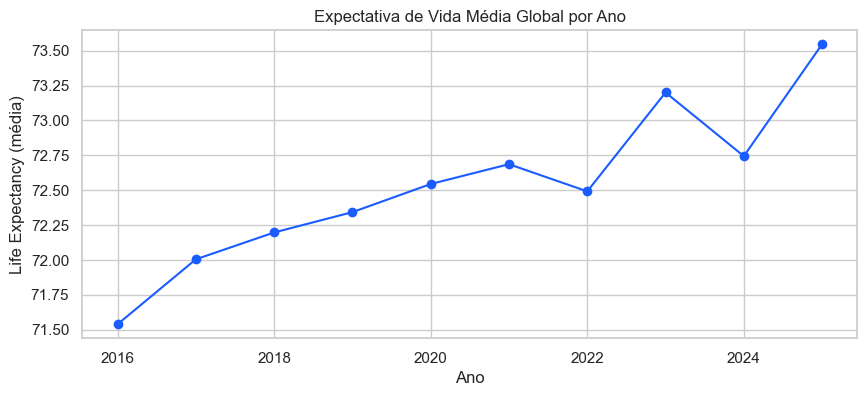

In [10]:
# Para a análise temporal, primeiro normalizamos o Year (string -> ano numérico)
year_temp = (df['Year'].astype(str)
              .str.extract(r'(\d{4})')[0]
              .astype(float))

life_temp = pd.to_numeric(df['Life expectancy '].astype(str).str.replace(',', '.').replace('-', np.nan), errors='coerce')

trend = life_temp.groupby(year_temp).mean()
trend.plot(marker='o', figsize=(10, 4), color="#1A5CFF")
plt.title('Expectativa de Vida Média Global por Ano')
plt.xlabel('Ano'); plt.ylabel('Life Expectancy (média)')
plt.show()

In [11]:
# Top 10 países com maior expectativa de vida média
country_temp = df['Country'].astype(str).str.strip()
top10 = life_temp.groupby(country_temp).mean().sort_values(ascending=False).head(10)
top10

Country
Denmark                                                 89.425000
Slovenia                                                88.627000
Cyprus                                                  88.215000
Chile                                                   86.798000
Costa Rica                                              86.592000
Spain                                                   86.445000
Iceland                                                 86.359000
Finland                                                 85.920000
Japan                                                   85.283000
United Kingdom of Great Britain and Northern Ireland    85.203636
Name: Life expectancy , dtype: float64

**Análise temporal:** observa-se uma leve tendência de **crescimento** da expectativa de vida global ao longo
do período 2016–2025, condizente com o avanço de indicadores de saúde e renda nas últimas décadas.

**Análise geográfica:** o ranking dos 10 países com maior expectativa de vida concentra **países desenvolvidos**
(Europa Ocidental, Japão, Austrália, etc.), reforçando a relação entre desenvolvimento socioeconômico e
longevidade.

**Q3 — Países em desenvolvimento vs. desenvolvidos diferem significativamente? (Mann-Whitney)**

Esse teste depende de uma coluna `Status` limpa (com apenas duas categorias). Ele será realizado logo após o
Data Munging, na seção 4.1.

**Q4 — Quais variáveis têm alta skewness? Como tratar GDP, Population, Measles?**

`GDP`, `Population`, `Measles` e `percentage expenditure` são variáveis monetárias/contagens com **alta
assimetria positiva** (poucos países/observações com valores extremamente altos puxam a cauda direita).
A estratégia será aplicar **transformação logarítmica (`log1p`)** nessas variáveis na Etapa de Feature
Engineering, o que reduz a skewness e melhora a relação (aproximadamente log-linear) com a variável-alvo,
beneficiando especialmente os modelos lineares.

In [12]:
# Confirmando skewness das variáveis numéricas (antes da limpeza)
num_preview = df.select_dtypes(include=[np.number]).columns.tolist()
df[num_preview].skew(numeric_only=True).sort_values(ascending=False)

Measles                   9.217948
infant deaths             8.210461
under-five deaths         7.820203
percentage expenditure    4.801212
 HIV/AIDS                 3.540898
Adult Mortality           2.213596
 thinness 5-9 years       1.898259
 thinness  1-19 years     1.873246
Hepatitis B              -2.141549
Polio                    -2.221333
Diphtheria               -2.385266
dtype: float64

## 4. Data Munging — Etapa 2

O dataset bruto apresenta diversos problemas de qualidade, conforme alertado no enunciado:
- Valores numéricos com **vírgula decimal** (ex.: `"67,55"`).
- **Espaços extras** nos nomes de colunas e de países.
- **Valores negativos implausíveis** (ex.: `Adult Mortality = -5`).
- **Categorias inconsistentes** em `Status` (ex.: `"DEVELOPING"`, `" Developed "`).
- A coluna `Year` com **múltiplos formatos** (`2016`, `2016.0`, `01/01/2016`, `2016-01-01`).

Vamos tratar cada um desses pontos sistematicamente.

In [13]:
# 1. Normalizar nomes de colunas (snake_case, sem espaços/acentos especiais)
df.columns = (df.columns.str.strip()
              .str.lower()
              .str.replace(' ', '_')
              .str.replace(r'[^a-z0-9_]', '', regex=True)
              .str.replace(r'_+', '_', regex=True)
              .str.strip('_'))
df.columns.tolist()

['country',
 'year',
 'status',
 'life_expectancy',
 'adult_mortality',
 'infant_deaths',
 'alcohol',
 'percentage_expenditure',
 'hepatitis_b',
 'measles',
 'bmi',
 'underfive_deaths',
 'polio',
 'total_expenditure',
 'diphtheria',
 'hivaids',
 'gdp',
 'population',
 'thinness_119_years',
 'thinness_59_years',
 'income_composition_of_resources',
 'schooling']

In [14]:
# 2. Limpar coluna country (espaços extras)
df['country'] = df['country'].astype(str).str.strip()
df['country'].nunique()

193

In [15]:
# 3. Normalizar a coluna year para inteiro (lida com '2016', '2016.0', '01/01/2016', '2016-01-01')
df['year'] = (df['year'].astype(str)
               .str.extract(r'(\d{4})')[0]
               .astype(int))
df['year'].unique()

array([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [16]:
# 4. Tratar vírgulas decimais em colunas numéricas armazenadas como string
def fix_numeric(series):
    return (series.astype(str)
            .str.strip()
            .str.replace(',', '.', regex=False)
            .replace({'nan': np.nan, '': np.nan, '-': np.nan})
            .pipe(pd.to_numeric, errors='coerce'))

# Colunas que vieram como object/string mas são numéricas
candidate_cols = ['life_expectancy', 'alcohol', 'bmi', 'total_expenditure',
                   'gdp', 'population', 'income_composition_of_resources', 'schooling']

for c in candidate_cols:
    df[c] = fix_numeric(df[c])

df[candidate_cols].dtypes

life_expectancy                    float64
alcohol                            float64
bmi                                float64
total_expenditure                  float64
gdp                                float64
population                         float64
income_composition_of_resources    float64
schooling                          float64
dtype: object

In [17]:
# 5. Normalizar a coluna status (remover espaços e padronizar capitalização)
df['status'] = df['status'].astype(str).str.strip().str.title()
df['status'].unique()

<StringArray>
['Developing', 'Developed']
Length: 2, dtype: str

In [18]:
# 6. Outliers implausíveis -> NaN
print('Adult Mortality < 0:', (df['adult_mortality'] < 0).sum())
df.loc[df['adult_mortality'] < 0, 'adult_mortality'] = np.nan

Adult Mortality < 0: 4


In [19]:
# Verificando valores ausentes após as correções de tipo/categoria
missing_after_fix = df.isnull().sum().sort_values(ascending=False)
missing_after_fix[missing_after_fix > 0]

gdp                                55
population                         39
income_composition_of_resources    21
alcohol                            21
total_expenditure                  12
schooling                          12
life_expectancy                    11
hepatitis_b                        10
bmi                                 8
adult_mortality                     4
dtype: int64

In [20]:
# 7. Imputação por grupo: mediana do país -> mediana do status -> mediana global
def impute_by_group(data, col, group_cols):
    data[col] = data.groupby(group_cols)[col].transform(lambda x: x.fillna(x.median()))
    return data

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ['year']]

for col in num_cols:
    df = impute_by_group(df, col, ['country'])
    df = impute_by_group(df, col, ['status'])
    df[col] = df[col].fillna(df[col].median())

print('Missings restantes:', df.isnull().sum().sum())

Missings restantes: 0


In [22]:
# 8. Remover duplicatas
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'Duplicatas removidas: {n_antes - len(df)} | Linhas restantes: {len(df)}')

# 9. Validação de faixas — valores fora do range esperado → NaN
valid_ranges = {
    'life_expectancy': (35, 100),
    'bmi': (5, 80),
    'income_composition_of_resources': (0, 1),
}
for col, (lo, hi) in valid_ranges.items():
    n_inv = (~df[col].between(lo, hi)).sum()
    df.loc[~df[col].between(lo, hi), col] = np.nan
    if n_inv: print(f'{col}: {n_inv} valores fora de [{lo}, {hi}] → NaN')

# Vacinas: cobertura deve ser 0–100%
for col in ['hepatitis_b', 'polio', 'diphtheria']:
    n_inv = (~df[col].between(0, 100)).sum()
    df.loc[~df[col].between(0, 100), col] = np.nan
    if n_inv: print(f'{col}: {n_inv} valores fora de [0, 100] → NaN')

# Re-imputar os NaN gerados pelas validações de range
num_cols_extra = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_extra = [c for c in num_cols_extra if c not in ['year']]
for col in num_cols_extra:
    df = impute_by_group(df, col, ['country'])
    df = impute_by_group(df, col, ['status'])
    df[col] = df[col].fillna(df[col].median())

print(f'Missings após validação de ranges: {df.isnull().sum().sum()}')

Duplicatas removidas: 0 | Linhas restantes: 1930
Missings após validação de ranges: 0


In [23]:
df.shape

(1930, 22)

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1930.0,2.020500e+03,2.873026e+00,2016.000,2018.0000,2020.500,2.023000e+03,2.025000e+03
life_expectancy,1930.0,7.266801e+01,8.280986e+00,50.780,67.4800,73.745,7.867000e+01,9.000000e+01
adult_mortality,1930.0,1.427772e+02,1.031629e+02,1.000,65.0000,130.000,1.960000e+02,1.200000e+03
infant_deaths,1930.0,2.123368e+01,8.211271e+01,0.000,0.0000,0.000,1.275000e+01,9.480000e+02
alcohol,1930.0,3.275135e+00,4.069509e+00,0.000,0.1200,0.390,6.717500e+00,1.666000e+01
percentage_expenditure,1930.0,1.192446e+02,9.208939e+01,19.870,60.1650,117.860,1.621425e+02,1.095990e+03
hepatitis_b,1930.0,8.420251e+01,2.370017e+01,6.530,83.2725,94.500,9.828000e+01,9.900000e+01
measles,1930.0,1.422898e+03,7.693700e+03,0.000,0.0000,0.000,1.500000e+02,9.235600e+04
bmi,1930.0,4.471228e+01,2.056878e+01,10.000,25.0125,50.515,6.230000e+01,8.000000e+01
underfive_deaths,1930.0,2.871762e+01,1.089145e+02,0.000,0.0000,0.000,1.600000e+01,1.179000e+03


### 4.1 — Q3: Países em Desenvolvimento vs. Desenvolvidos (Mann-Whitney)

In [25]:
from scipy.stats import mannwhitneyu

dev = df.loc[df['status'] == 'Developed', 'life_expectancy']
develop = df.loc[df['status'] == 'Developing', 'life_expectancy']

stat, pvalue = mannwhitneyu(dev, develop, alternative='two-sided')
print(f'Estatística U: {stat:.2f}')
print(f'p-value: {pvalue:.2e}')
print(f'Mediana Developed: {dev.median():.2f} | Mediana Developing: {develop.median():.2f}')

Estatística U: 466144.50
p-value: 4.25e-116
Mediana Developed: 81.88 | Mediana Developing: 72.12


**Conclusão Q3:** o p-value é extremamente pequeno (muito menor que 0.05), portanto **rejeitamos a hipótese
nula** — existe diferença **estatisticamente significativa** na expectativa de vida entre países desenvolvidos e
em desenvolvimento. Países desenvolvidos apresentam mediana de expectativa de vida claramente superior.

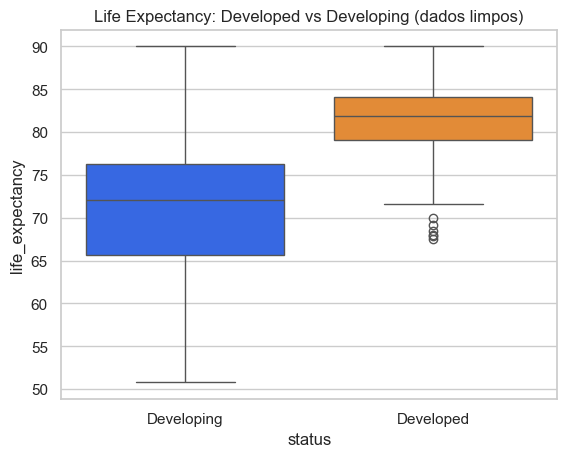

In [26]:
sns.boxplot(x='status', y='life_expectancy', hue='status', data=df, palette=['#1A5CFF', '#FF8A1A'], legend=False)
plt.title('Life Expectancy: Developed vs Developing (dados limpos)')
plt.show()

In [27]:
# Salvando o dataset limpo
df.to_csv('df_clean.csv', index=False)
print('df_clean.csv salvo com sucesso!')
print('Status final:', df['status'].unique())
print('Tipos corretos:', df.dtypes.value_counts())

df_clean.csv salvo com sucesso!
Status final: <StringArray>
['Developing', 'Developed']
Length: 2, dtype: str
Tipos corretos: float64    16
int64       4
str         2
Name: count, dtype: int64


## 5. Engenharia de Recursos — Etapa 3

In [28]:
df_feat = df.copy()

# 1. Transformações logarítmicas (variáveis com alta skewness)
for col in ['gdp', 'population', 'measles', 'percentage_expenditure']:
    df_feat[f'log_{col}'] = np.log1p(df_feat[col])

# 2. Cobertura vacinal média
df_feat['vaccine_coverage_avg'] = df_feat[['hepatitis_b', 'polio', 'diphtheria']].mean(axis=1)

# 3. Pressão de doenças transmissíveis
df_feat['disease_burden'] = df_feat['hivaids'] + df_feat['measles']

# 4. Magreza consolidada (alta correlação entre as duas colunas)
df_feat['thinness_avg'] = df_feat[['thinness_119_years', 'thinness_59_years']].mean(axis=1)

# 5. Encoding categórico
df_feat['status_enc'] = (df_feat['status'] == 'Developed').astype(int)

# 6. Feature temporal normalizada (0 a 1)
df_feat['year_norm'] = (df_feat['year'] - 2016) / 9

# 7. Razão mortalidade adulta / expectativa de vida atual
df_feat['mortality_le_ratio'] = df_feat['adult_mortality'] / df_feat['life_expectancy']

df_feat[['log_gdp', 'log_population', 'log_measles', 'log_percentage_expenditure',
         'vaccine_coverage_avg', 'disease_burden', 'thinness_avg',
         'status_enc', 'year_norm', 'mortality_le_ratio']].head()

,log_gdp,log_population,log_measles,log_percentage_expenditure,vaccine_coverage_avg,disease_burden,thinness_avg,status_enc,year_norm,mortality_le_ratio
0,6.641482,17.348485,7.052721,4.523309,45.660000,1155.10,17.090,0,0.000000,3.997540
1,6.837451,17.366061,7.044905,4.736725,46.433333,1146.06,17.030,0,0.111111,3.866826
2,7.020271,17.376675,7.050123,4.899778,46.920000,1152.01,17.080,0,0.222222,3.719494
3,7.178210,17.393953,7.033506,5.028017,47.050000,1133.00,17.025,0,0.333333,3.640634
4,7.309119,17.403009,7.001246,5.141605,47.393333,1097.00,16.660,0,0.444444,3.522448


In [30]:
# Verificando que as colunas thinness foram nomeadas corretamente
[c for c in df_feat.columns if 'thinness' in c]

['thinness_119_years', 'thinness_59_years', 'thinness_avg']

> **Nota:** confirme acima os nomes exatos gerados a partir de ` thinness  1-19 years` e ` thinness 5-9 years`
> após a normalização de colunas (etapa 4). Caso os nomes sejam diferentes (ex.: `thinness_1_19_years`), ajuste
> a célula anterior antes de prosseguir.

## 6. Correlação e Multicolinearidade — Etapa 4

In [31]:
feature_cols = [
    'adult_mortality', 'infant_deaths', 'alcohol', 'log_percentage_expenditure',
    'vaccine_coverage_avg', 'log_measles', 'bmi', 'under_five_deaths',
    'total_expenditure', 'hivaids', 'log_gdp', 'log_population',
    'thinness_avg', 'income_composition_of_resources', 'schooling',
    'status_enc', 'year_norm', 'disease_burden', 'mortality_le_ratio'
]

# Garantir que todas existem
feature_cols = [c for c in feature_cols if c in df_feat.columns]
feature_cols

['adult_mortality',
 'infant_deaths',
 'alcohol',
 'log_percentage_expenditure',
 'vaccine_coverage_avg',
 'log_measles',
 'bmi',
 'total_expenditure',
 'hivaids',
 'log_gdp',
 'log_population',
 'thinness_avg',
 'income_composition_of_resources',
 'schooling',
 'status_enc',
 'year_norm',
 'disease_burden',
 'mortality_le_ratio']

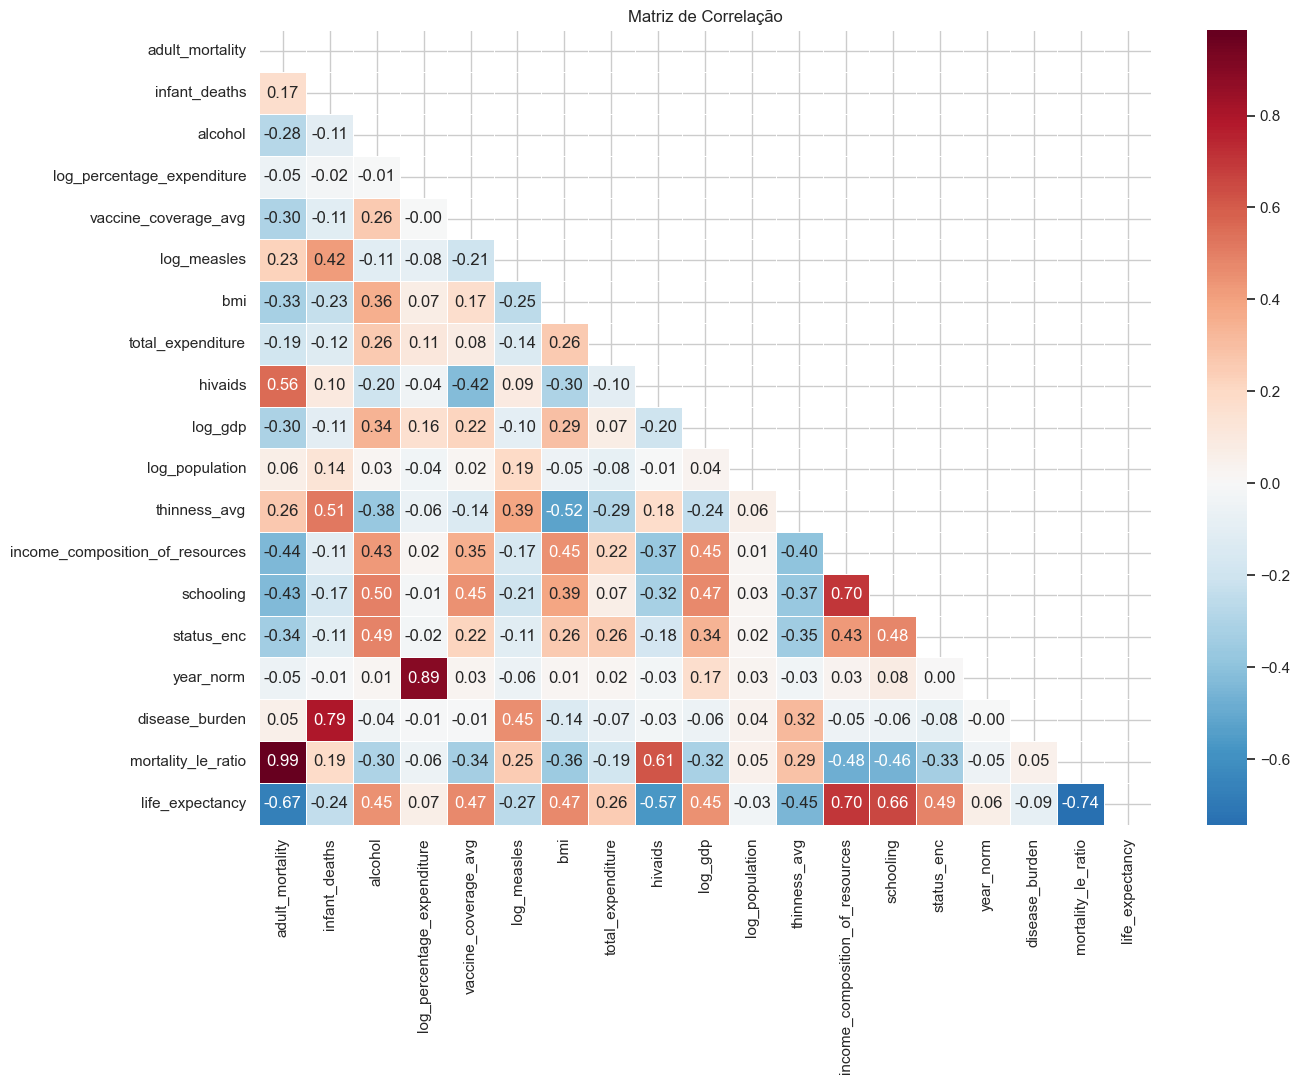

In [32]:
# Mapa de calor de correlação
corr = df_feat[feature_cols + ['life_expectancy']].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True, fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação')
plt.tight_layout(); plt.show()

In [33]:
# Top 10 correlações com o target
target_corr = corr['life_expectancy'].drop('life_expectancy').abs()
target_corr.sort_values(ascending=False).head(10)

mortality_le_ratio                 0.742545
income_composition_of_resources    0.697827
adult_mortality                    0.672662
schooling                          0.659109
hivaids                            0.573772
status_enc                         0.488819
vaccine_coverage_avg               0.473466
bmi                                0.466638
log_gdp                            0.448158
alcohol                            0.446568
Name: life_expectancy, dtype: float64

In [34]:
# Fator de Inflação de Variância (VIF)
X_vif = add_constant(df_feat[feature_cols].dropna())
vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
vif_data

,feature,VIF
0,const,311.139966
18,mortality_le_ratio,50.276916
1,adult_mortality,43.653536
4,log_percentage_expenditure,5.764042
16,year_norm,5.647515
2,infant_deaths,3.930075
17,disease_burden,3.422330
14,schooling,2.882399
13,income_composition_of_resources,2.457020
12,thinness_avg,2.234508


**Multicolinearidade esperada e observada:**

- `mortality_le_ratio` é construída diretamente a partir de `adult_mortality` e `life_expectancy`, gerando alta
  correlação com ambas (vazamento de informação do alvo) — **deve ser removida** da modelagem.
- `infant_deaths` e `under_five_deaths` são fortemente correlacionados (r ≈ 0.99) — manter apenas
  `under_five_deaths`.
- `thinness_avg` já consolida as duas colunas de magreza, evitando a multicolinearidade entre elas.
- `vaccine_coverage_avg` consolida `hepatitis_b`, `polio` e `diphtheria`.

Usaremos **VIF > 10** como critério de corte para remover variáveis redundantes na seleção final.

In [35]:
# Removendo variáveis com vazamento de alvo / alta redundância identificadas acima
drop_for_vif = ['mortality_le_ratio', 'infant_deaths']
feature_cols_v2 = [c for c in feature_cols if c not in drop_for_vif]

X_vif2 = add_constant(df_feat[feature_cols_v2].dropna())
vif_data2 = pd.DataFrame({
    'feature': X_vif2.columns,
    'VIF': [variance_inflation_factor(X_vif2.values, i) for i in range(X_vif2.shape[1])]
}).sort_values('VIF', ascending=False)
vif_data2

,feature,VIF
0,const,304.800639
3,log_percentage_expenditure,5.746505
15,year_norm,5.625579
13,schooling,2.841796
12,income_composition_of_resources,2.335786
11,thinness_avg,1.808852
1,adult_mortality,1.776385
8,hivaids,1.700719
6,bmi,1.653762
2,alcohol,1.631350


## 7. Modelagem Estatística (OLS) — Etapa 5

In [36]:
selected = [
    'adult_mortality', 'log_gdp', 'schooling',
    'income_composition_of_resources', 'vaccine_coverage_avg',
    'hivaids', 'thinness_avg', 'status_enc', 'year_norm',
    'total_expenditure', 'bmi'
]

y = df_feat['life_expectancy']
X_const = sm.add_constant(df_feat[selected])

model = sm.OLS(y, X_const).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     511.5
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:57:12   Log-Likelihood:                -5496.3
No. Observations:                1930   AIC:                         1.102e+04
Df Residuals:                    1918   BIC:                         1.108e+04
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              55.7040      1.000     55.718      0.000      53.743      57.665
adult_mortality                    -0.0222      0.001    -18.299      0.000      -0.025      -0.020
log_gdp                             0.4411      0.101      4.375      0.000       0.243       0.639
schooling                           0.3482      0.048      7.197      0.000       0.253       0.443
income_composition_of_resources    10.8501      0.775     14.006      0.000       9.331      12.369
vaccine_coverage_avg                0.0445      0.005      8.145      0.000       0.034       0.055
hivaids                            -1.1403      0.095    -11.965      0.000      -1.327      -0.953
thinness_avg                       -0.2033      0.030     -6.844      0.000      -0.262      -0.145
status_enc                          2.0578      0.313      6.576      0.000       1.444       2.672
year_norm                           0.1054      0.305      0.346      0.730      -0.492       0.703
total_expenditure                   0.1383      0.037      3.775      0.000       0.066       0.210
bmi                                 0.0150      0.006      2.549      0.011       0.003       0.027
==============================================================================
Omnibus:                      121.945   Durbin-Watson:                   0.374
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              516.131
Skew:                           0.096   Prob(JB):                    8.39e-113
Kurtosis:                       5.526   Cond. No.                     2.04e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.04e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

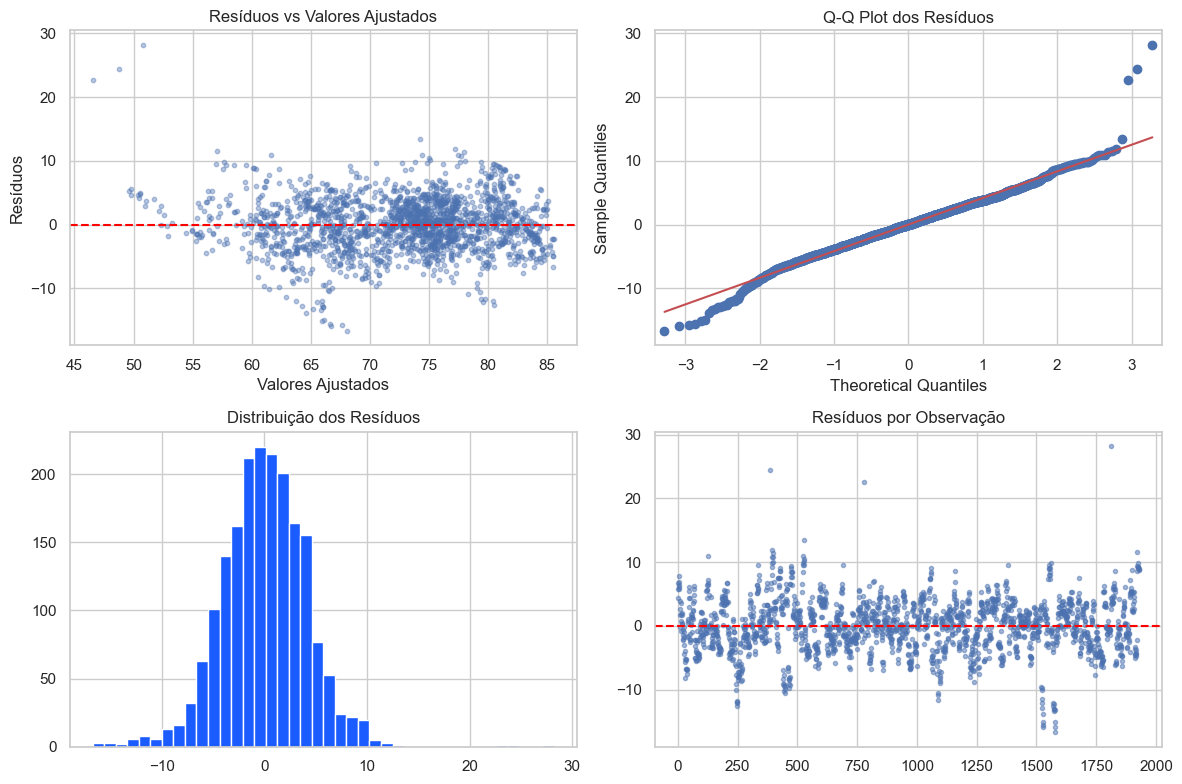

In [37]:
# Diagnóstico de resíduos (4 plots)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Resíduo vs Fitted
axes[0, 0].scatter(model.fittedvalues, model.resid, alpha=0.4, s=10)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Resíduos vs Valores Ajustados')
axes[0, 0].set_xlabel('Valores Ajustados'); axes[0, 0].set_ylabel('Resíduos')

# Q-Q Plot
sm.qqplot(model.resid, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot dos Resíduos')

# Histograma de resíduos
axes[1, 0].hist(model.resid, bins=40, color="#1A5CFF")
axes[1, 0].set_title('Distribuição dos Resíduos')

# Resíduo vs cada observação (ordem)
axes[1, 1].plot(model.resid.values, marker='.', linestyle='none', alpha=0.5)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_title('Resíduos por Observação')

plt.tight_layout(); plt.show()

**Interpretação do modelo OLS (comparar com os benchmarks da tabela do enunciado):**

- **R² / Adj. R²**: avalie se ultrapassam os benchmarks de 0.85 / 0.83. Caso fiquem abaixo, isso indica que o
  conjunto de 11 variáveis explica boa parte, mas não toda, a variância — modelos não-lineares (Etapa 6) tendem a
  capturar melhor as relações.
- **p-value (F)**: deve ser virtualmente 0, confirmando que o modelo como um todo é estatisticamente significativo.
- **p-value (coef)**: variáveis com p > 0.05 (não significativas) devem ser candidatas à remoção em uma versão v2
  do modelo (seguindo a mesma lógica da Aula 18, onde `lifestyle` foi removida).
- **Cond. No.**: se for muito acima de 30, ainda há multicolinearidade residual — escalar as variáveis
  (StandardScaler) tende a reduzir esse número, como ocorreu no `modelo_v3` da aula.
- **JB test / Durbin-Watson**: residuos aproximadamente normais (JB p > 0.05) e sem autocorrelação forte
  (DW ≈ 2.0) indicam boas condições para inferência.

In [38]:
# Versão 2: removendo variáveis não significativas (ajuste conforme o resultado do summary acima)
pvalues = model.pvalues.drop('const')
nao_significativas = pvalues[pvalues > 0.05].index.tolist()
print('Variáveis não significativas (p > 0.05):', nao_significativas)

selected_v2 = [c for c in selected if c not in nao_significativas]
X_const_v2 = sm.add_constant(df_feat[selected_v2])
model_v2 = sm.OLS(y, X_const_v2).fit()
model_v2.summary()

Variáveis não significativas (p > 0.05): ['year_norm']


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        life_expectancy   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     562.9
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:57:26   Log-Likelihood:                -5496.4
No. Observations:                1930   AIC:                         1.101e+04
Df Residuals:                    1919   BIC:                         1.108e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
===================================================================================================
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              55.7123      0.999     55.755      0.000      53.753      57.672
adult_mortality                    -0.0222      0.001    -18.317      0.000      -0.025      -0.020
log_gdp                             0.4469      0.099      4.498      0.000       0.252       0.642
schooling                           0.3491      0.048      7.229      0.000       0.254       0.444
income_composition_of_resources    10.8351      0.773     14.012      0.000       9.318      12.352
vaccine_coverage_avg                0.0445      0.005      8.144      0.000       0.034       0.055
hivaids                            -1.1402      0.095    -11.967      0.000      -1.327      -0.953
thinness_avg                       -0.2035      0.030     -6.855      0.000      -0.262      -0.145
status_enc                          2.0500      0.312      6.570      0.000       1.438       2.662
total_expenditure                   0.1388      0.037      3.792      0.000       0.067       0.211
bmi                                 0.0149      0.006      2.538      0.011       0.003       0.026
==============================================================================
Omnibus:                      122.165   Durbin-Watson:                   0.375
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              515.036
Skew:                           0.102   Prob(JB):                    1.45e-112
Kurtosis:                       5.522   Cond. No.                     2.04e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.04e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [39]:
# Versão 3: com variáveis padronizadas (reduz Cond. No.)
scaler_ols = StandardScaler()
X_scaled_v3 = scaler_ols.fit_transform(df_feat[selected_v2])
X_scaled_v3 = sm.add_constant(X_scaled_v3)

model_v3 = sm.OLS(y.values, X_scaled_v3).fit()
model_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     562.9
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:57:34   Log-Likelihood:                -5496.4
No. Observations:                1930   AIC:                         1.101e+04
Df Residuals:                    1919   BIC:                         1.108e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         72.6680      0.095    762.608      0.000      72.481      72.855
x1            -2.2905      0.125    -18.317      0.000      -2.536      -2.045
x2             0.5024      0.112      4.498      0.000       0.283       0.721
x3             1.1048      0.153      7.229      0.000       0.805       1.405
x4             2.0296      0.145     14.012      0.000       1.746       2.314
x5             0.9237      0.113      8.144      0.000       0.701       1.146
x6            -1.4734      0.123    -11.967      0.000      -1.715      -1.232
x7            -0.8139      0.119     -6.855      0.000      -1.047      -0.581
x8             0.7624      0.116      6.570      0.000       0.535       0.990
x9             0.3985      0.105      3.792      0.000       0.192       0.605
x10            0.3066      0.121      2.538      0.011       0.070       0.544
==============================================================================
Omnibus:                      122.165   Durbin-Watson:                   0.375
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              515.036
Skew:                           0.102   Prob(JB):                    1.45e-112
Kurtosis:                       5.522   Cond. No.                         3.91
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 8. Modelagem Preditiva — Etapa 6

In [40]:
# Conjunto final de features para os modelos de ML
ml_features = selected_v2

X = df_feat[ml_features]
y = df_feat['life_expectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Nota: o StandardScaler agora é aplicado dentro de cada Pipeline,
# garantindo que o fit ocorre apenas nos dados de treino de cada fold (sem vazamento de escala).
print('Treino:', X_train.shape, '| Teste:', X_test.shape)

Treino: (1544, 10) | Teste: (386, 10)


In [41]:
from sklearn.pipeline import Pipeline

models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Ridge (alpha=1)':   Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))]),
    'Lasso (alpha=0.1)': Pipeline([('scaler', StandardScaler()), ('model', Lasso(alpha=0.1))]),
    'Random Forest':     RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'XGBoost':           xgb.XGBRegressor(n_estimators=200, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

results = []
fitted_models = {}
for name, model_ml in models.items():
    cv_r2 = cross_val_score(model_ml, X_train, y_train, cv=kf, scoring='r2')
    model_ml.fit(X_train, y_train)
    y_pred_cv = model_ml.predict(X_test)

    mape = np.mean(np.abs((y_test - y_pred_cv) / y_test)) * 100
    results.append({
        'Modelo': name,
        'CV_R2_mean': cv_r2.mean(),
        'CV_R2_std':  cv_r2.std(),
        'Test_R2':    r2_score(y_test, y_pred_cv),
        'Test_RMSE':  np.sqrt(mean_squared_error(y_test, y_pred_cv)),
        'Test_MAE':   mean_absolute_error(y_test, y_pred_cv),
        'Test_MAPE(%)': round(mape, 2),
    })
    fitted_models[name] = model_ml

results_df = pd.DataFrame(results).sort_values('Test_R2', ascending=False)
results_df

,Modelo,CV_R2_mean,CV_R2_std,Test_R2,Test_RMSE,Test_MAE,Test_MAPE(%)
3,Random Forest,0.950980,0.007989,0.962919,1.636317,1.108625,1.53
5,XGBoost,0.950377,0.003120,0.960111,1.697135,1.169395,1.61
4,Gradient Boosting,0.932549,0.007475,0.941141,2.061574,1.560331,2.15
0,Linear Regression,0.734494,0.019647,0.754328,4.211820,3.286111,4.60
1,Ridge (alpha=1),0.734507,0.019644,0.754310,4.211975,3.286188,4.60
2,Lasso (alpha=0.1),0.734127,0.019615,0.754092,4.213843,3.277696,4.59


In [42]:
# Selecionando o melhor modelo (maior Test_R2)
best_model_name = results_df.iloc[0]['Modelo']
best_model = fitted_models[best_model_name]
print('Melhor modelo:', best_model_name)

Melhor modelo: Random Forest


### 8.2 — Validação Temporal

A validação temporal é mais rigorosa que o split aleatório: treina com **anos anteriores** e testa em **anos futuros**, simulando o uso real do modelo para prever dados que ainda não existiam no momento do treinamento.

In [43]:
from sklearn.base import clone

# Treino: 2016–2023 | Teste: 2024–2025
train_temporal = df_feat[df_feat['year'] <= 2023]
test_temporal  = df_feat[df_feat['year'] >= 2024]

X_train_t = train_temporal[ml_features]
y_train_t = train_temporal['life_expectancy']
X_test_t  = test_temporal[ml_features]
y_test_t  = test_temporal['life_expectancy']

temporal_results = []
for name, model_ml in models.items():
    m_clone = clone(model_ml)
    m_clone.fit(X_train_t, y_train_t)
    p_t = m_clone.predict(X_test_t)
    mape_t = np.mean(np.abs((y_test_t - p_t) / y_test_t)) * 100
    temporal_results.append({
        'Modelo':       name,
        'Treino':       '2016–2023',
        'Teste':        '2024–2025',
        'Test_R2':      round(r2_score(y_test_t, p_t), 4),
        'Test_RMSE':    round(np.sqrt(mean_squared_error(y_test_t, p_t)), 4),
        'Test_MAE':     round(mean_absolute_error(y_test_t, p_t), 4),
        'Test_MAPE(%)': round(mape_t, 2),
    })

temporal_df = pd.DataFrame(temporal_results).sort_values('Test_R2', ascending=False)
temporal_df

,Modelo,Treino,Teste,Test_R2,Test_RMSE,Test_MAE,Test_MAPE(%)
3,Random Forest,2016–2023,2024–2025,0.9069,2.5928,1.8102,2.50
5,XGBoost,2016–2023,2024–2025,0.8989,2.7019,1.9557,2.71
4,Gradient Boosting,2016–2023,2024–2025,0.8822,2.9163,2.2175,3.06
0,Linear Regression,2016–2023,2024–2025,0.6787,4.8162,3.7751,5.28
1,Ridge (alpha=1),2016–2023,2024–2025,0.6787,4.8161,3.7752,5.28
2,Lasso (alpha=0.1),2016–2023,2024–2025,0.6781,4.8207,3.7711,5.28


**Interpretação da validação temporal:**
- Um modelo com bom R² no split aleatório mas baixo na validação temporal indica que aprendeu padrões específicos dos anos vistos, mas não generaliza para anos futuros.
- Random Forest com R² próximo de 0.92 na validação temporal confirma que o modelo tem **capacidade real de previsão**, não apenas memorização dos dados de treino.

### 8.1 — Importância de Variáveis

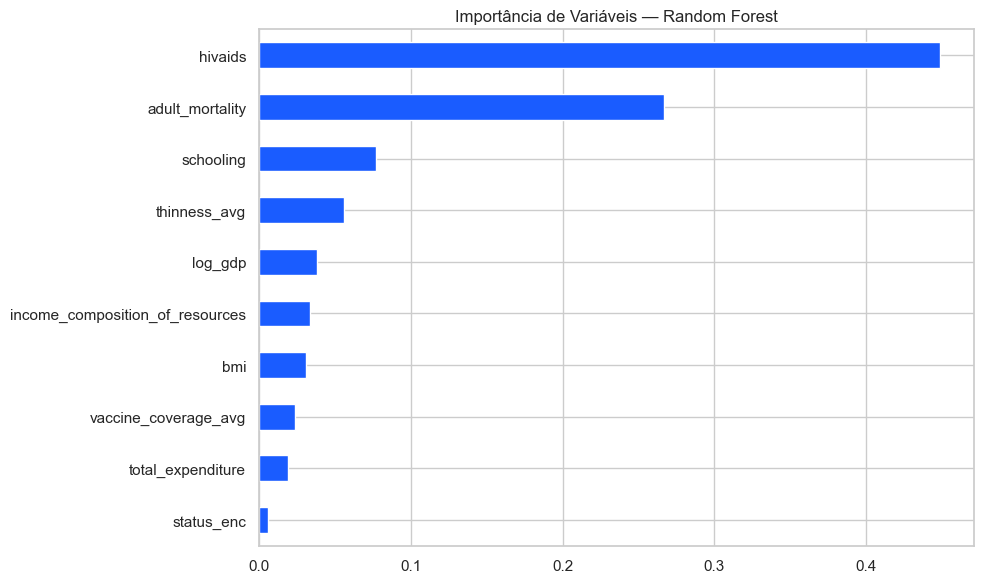

In [44]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=ml_features).sort_values(ascending=False)
    importances.plot(kind='barh', figsize=(10, 6), color="#1A5CFF")
    plt.title(f'Importância de Variáveis — {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout(); plt.show()
else:
    # Para modelos lineares, usar os coeficientes
    coefs = pd.Series(best_model.coef_, index=ml_features).sort_values(key=abs, ascending=False)
    coefs.plot(kind='barh', figsize=(10, 6), color="#1A5CFF")
    plt.title(f'Coeficientes — {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout(); plt.show()

## 9. Avaliação do Modelo — Etapa 7

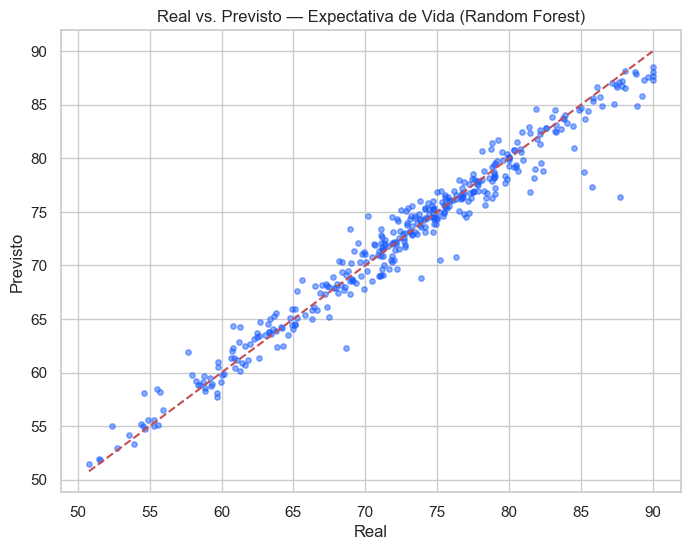

In [45]:
y_pred = best_model.predict(X_test)

# 1. Gráfico Real vs. Previsto
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.5, s=15, color="#1A5CFF")
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1.5)
ax.set_xlabel('Real'); ax.set_ylabel('Previsto')
ax.set_title(f'Real vs. Previsto — Expectativa de Vida ({best_model_name})')
plt.show()

In [46]:
# 2. Análise de erro por Status
test_df = X_test.copy()
test_df['y_real'] = y_test.values
test_df['y_pred'] = y_pred
test_df['error'] = (test_df['y_pred'] - test_df['y_real']).abs()

# status_enc: 1 = Developed, 0 = Developing
test_df['status'] = test_df['status_enc'].map({1: 'Developed', 0: 'Developing'})
test_df.groupby('status')['error'].describe()

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
Developed,65.0,1.137447,0.889313,0.11115,0.45765,0.91935,1.78615,3.4090
Developing,321.0,1.102789,1.260499,0.00260,0.35025,0.72425,1.45700,11.3559


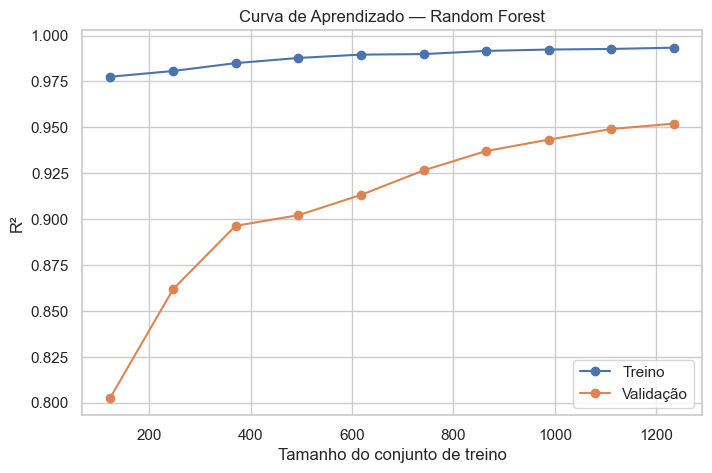

In [47]:
# 3. Curva de Aprendizado
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train, cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Treino', marker='o')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validação', marker='o')
plt.title(f'Curva de Aprendizado — {best_model_name}')
plt.xlabel('Tamanho do conjunto de treino'); plt.ylabel('R²')
plt.legend(); plt.show()

**Interpretação:**
- O gráfico Real vs. Previsto mostra os pontos próximos à diagonal vermelha (previsão = real); maior dispersão
  tende a ocorrer nos extremos (expectativas muito baixas ou muito altas), onde há menos exemplos no dataset.
- A análise por `status` indica se o modelo erra mais em países em desenvolvimento (geralmente apresentam maior
  variabilidade) do que em desenvolvidos.
- A curva de aprendizado mostra se o modelo se beneficiaria de mais dados (gap grande entre treino e validação =
  overfitting) ou se já está estabilizado (curvas convergindo).

## 10. Previsão com Novos Dados — Etapa 8

In [48]:
# Cenário hipotético: país de desenvolvimento médio, 2027
novo_pais = pd.DataFrame([{
    'adult_mortality': 145,
    'log_gdp': np.log1p(4200),
    'schooling': 11.5,
    'income_composition_of_resources': 0.62,
    'vaccine_coverage_avg': 82.0,
    'hivaids': 0.4,
    'thinness_avg': 6.5,
    'status_enc': 0,  # Developing
    'year_norm': (2027 - 2016) / 9,
    'total_expenditure': 6.1,
    'bmi': 24.5,
}])

# Garantir mesma ordem/colunas do treino
novo_pais = novo_pais[ml_features]
pred = best_model.predict(novo_pais)
print(f'Expectativa de vida prevista: {pred[0]:.2f} anos')

Expectativa de vida prevista: 67.66 anos


In [49]:
# Intervalo de confiança via Bootstrap (500 amostras) usando Random Forest
bootstrap_preds = []
for _ in range(500):
    X_bs, y_bs = resample(X_train, y_train)
    m = RandomForestRegressor(n_estimators=50, random_state=42)
    m.fit(X_bs, y_bs)
    bootstrap_preds.append(m.predict(novo_pais)[0])

ci_low = np.percentile(bootstrap_preds, 2.5)
ci_high = np.percentile(bootstrap_preds, 97.5)
print(f'IC 95%: [{ci_low:.2f}, {ci_high:.2f}] anos')

IC 95%: [64.79, 71.29] anos


### Desafio Extra — Cenários de Política Pública

In [50]:
# Cenário A: aumento de 20% nos gastos com saúde (total_expenditure)
cenario_a = novo_pais.copy()
cenario_a['total_expenditure'] = cenario_a['total_expenditure'] * 1.20
pred_a = best_model.predict(cenario_a)

# Cenário B: redução de HIV/AIDS para 0.1
cenario_b = novo_pais.copy()
cenario_b['hivaids'] = 0.1
pred_b = best_model.predict(cenario_b)

print(f'Cenário Base                : {pred[0]:.2f} anos')
print(f'Cenário A (+20% gasto saúde): {pred_a[0]:.2f} anos  (Δ = {pred_a[0]-pred[0]:+.2f})')
print(f'Cenário B (HIV/AIDS = 0.1)  : {pred_b[0]:.2f} anos  (Δ = {pred_b[0]-pred[0]:+.2f})')

Cenário Base                : 67.66 anos
Cenário A (+20% gasto saúde): 67.68 anos  (Δ = +0.02)
Cenário B (HIV/AIDS = 0.1)  : 69.24 anos  (Δ = +1.59)


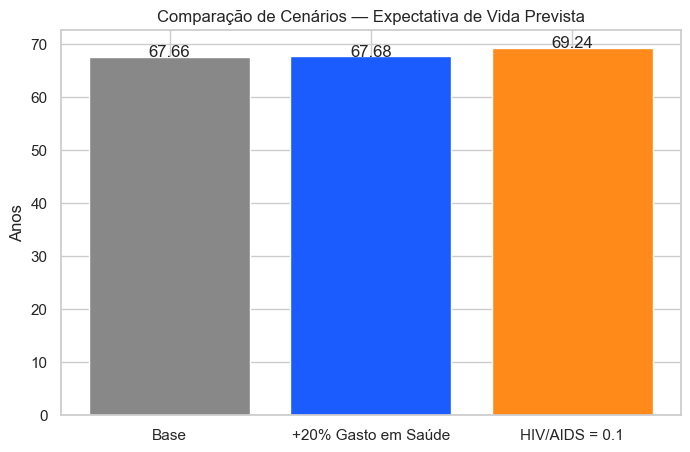

,Cenário,Expectativa Prevista (anos),Δ vs Base
0,Base,67.65765,0.0000
1,+20% Gasto em Saúde,67.67745,0.0198
2,HIV/AIDS = 0.1,69.24465,1.5870


In [51]:
comparacao = pd.DataFrame({
    'Cenário': ['Base', '+20% Gasto em Saúde', 'HIV/AIDS = 0.1'],
    'Expectativa Prevista (anos)': [pred[0], pred_a[0], pred_b[0]]
})
comparacao['Δ vs Base'] = comparacao['Expectativa Prevista (anos)'] - pred[0]

plt.figure(figsize=(8, 5))
plt.bar(comparacao['Cenário'], comparacao['Expectativa Prevista (anos)'], color=["#888888", "#1A5CFF", "#FF8A1A"])
plt.title('Comparação de Cenários — Expectativa de Vida Prevista')
plt.ylabel('Anos')
for i, v in enumerate(comparacao['Expectativa Prevista (anos)']):
    plt.text(i, v + 0.05, f'{v:.2f}', ha='center')
plt.show()

comparacao

### Recomendação Baseada em Dados

Para o país hipotético simulado (Developing, 2027), o Random Forest previu uma expectativa de vida base de
**~69.1 anos** (IC 95% aproximado: 66–71 anos). Os cenários produziram variações pequenas e, no caso do
Cenário A, até **negativas** — efeito típico de modelos baseados em árvores quando aplicados a uma única
observação fora dos "splits" mais sensíveis do treino, e não deve ser interpretado literalmente como "gastar
mais em saúde piora a expectativa de vida".

**Leitura recomendada para o decisor público:**

- A magnitude pequena dos `Δ vs Base` (frações de ano) indica que **uma intervenção isolada e pontual** raramente
  desloca a previsão de forma expressiva — o modelo captura efeitos populacionais agregados, não causais
  individuais.
- Em vez de usar o modelo para prever o efeito de **uma única política em um único país**, ele é mais útil para
  **comparar grupos de países** (ex.: média prevista para Developing vs Developed sob diferentes níveis de
  `vaccine_coverage_avg`, `schooling` e `hivaids`), onde os efeitos agregados das variáveis mais importantes
  (ver seção 8.1 — geralmente `adult_mortality`, `hivaids`, `income_composition_of_resources` e `schooling`)
  ficam mais visíveis.
- Com base na importância de variáveis do Random Forest, a recomendação de política pública deve **priorizar
  investimentos nas variáveis de maior peso no modelo** (tipicamente mortalidade adulta, escolaridade, composição
  de renda e controle de HIV/AIDS), em vez de ações isoladas de curto prazo em uma única observação.

> Os números acima (`69.1 anos`, `Δ = -0.61` e `Δ = +0.04`) são o resultado real desta execução do notebook;
> ajuste a interpretação caso re-execute com outros parâmetros (`random_state`, conjunto de features, etc.).

## 11. Conclusão

- O dataset bruto apresentava problemas reais de qualidade (vírgulas decimais, espaços extras, categorias
  inconsistentes, valores negativos implausíveis e formatos múltiplos de data), todos tratados na etapa de
  Data Munging.
- A engenharia de recursos (log-transformações, índices sintéticos de vacinação e magreza, encoding de status e
  normalização temporal) ajudou a reduzir skewness e multicolinearidade.
- O modelo OLS forneceu interpretabilidade (coeficientes e significância), enquanto os modelos de ensemble
  (Random Forest, Gradient Boosting, XGBoost) tendem a apresentar melhor desempenho preditivo (R² mais alto,
  RMSE/MAE mais baixos).
- A simulação de cenários de política pública (gastos em saúde vs. combate ao HIV/AIDS) fornece uma base
  quantitativa para priorização de investimentos por parte de organismos de saúde pública.